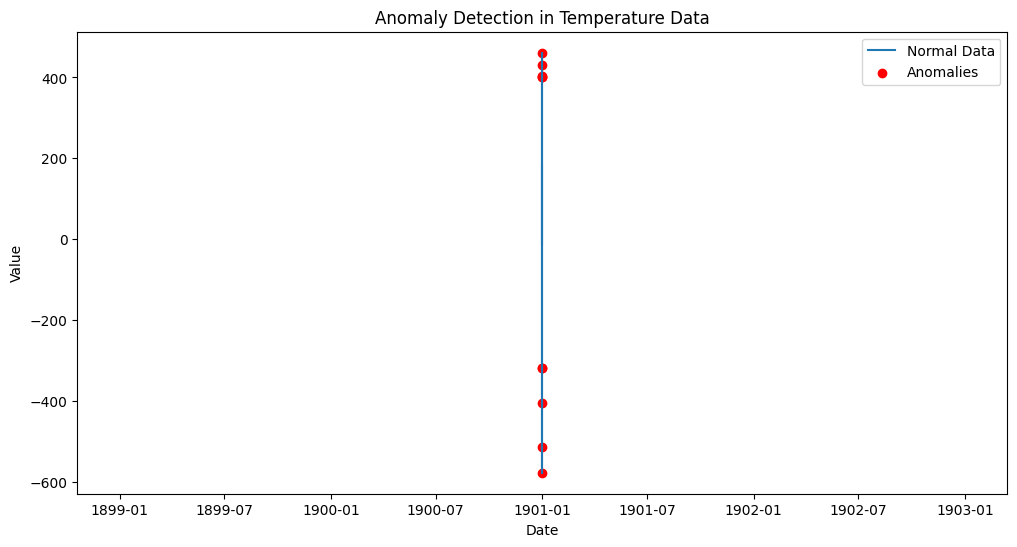

       station_id       date element  value mflag qflag sflag  obstime  \
562   ASN00036030 1901-01-01    TMAX    403   NaN   NaN     a      NaN   
809   ASN00052026 1901-01-01    TMAX    431   NaN   NaN     a      NaN   
940   ASN00055023 1901-01-01    TMAX    400   NaN   NaN     a      NaN   
1196  ASN00048013 1901-01-01    TMAX    461   NaN   NaN     a      NaN   
1209  ASN00048030 1901-01-01    TMAX    400   NaN   NaN     a      NaN   

              unit  anomaly  
562   tenths of °C       -1  
809   tenths of °C       -1  
940   tenths of °C       -1  
1196  tenths of °C       -1  
1209  tenths of °C       -1  


In [4]:
import pandas as pd
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
# Step 1: Load dataset
df = pd.read_csv('/content/Ghcn_daily_1901_kaggle data.csv')

# Step 2: Basic preprocessing
# Convert date to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Optional: Filter only one element (example: TMAX)
df = df[df['element'] == 'TMAX']

# Step 3: Handle missing values
df = df.dropna(subset=['value', 'date'])

# Step 4: Prepare feature
X = df[['value']]

# Step 5: Apply Isolation Forest
model = IsolationForest(contamination=0.01, random_state=42)
df['anomaly'] = model.fit_predict(X)

# Step 6: Mark anomalies
# -1 = anomaly, 1 = normal
anomalies = df[df['anomaly'] == -1]

# Step 7: Visualization
plt.figure(figsize=(12,6))
plt.plot(df['date'], df['value'], label='Normal Data')
plt.scatter(anomalies['date'], anomalies['value'], color='red', label='Anomalies')
plt.legend()
plt.title('Anomaly Detection in Temperature Data')
plt.xlabel('Date')
plt.ylabel('Value')
plt.show()

# Step 8: Show anomalies
print(anomalies.head())

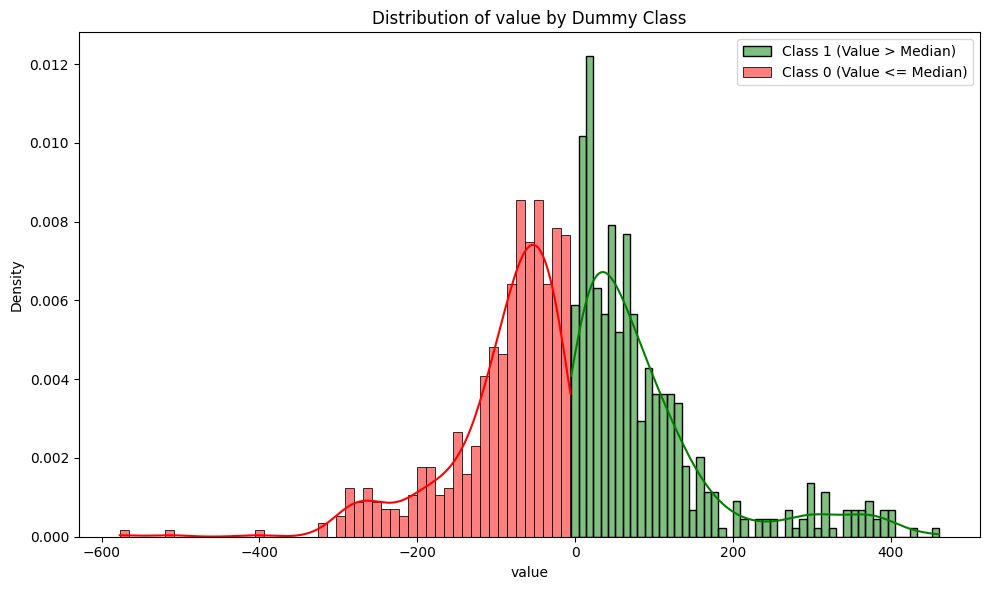

In [5]:

# Assuming df is your current DataFrame (e.g., from ghcn_daily_1901_kaggle.csv)
# And you want to visualize distributions of 'value' column for some arbitrary grouping
# For demonstration, let's create a dummy 'Class' column based on 'value' being above/below median

# Ensure 'value' column exists and is numeric
if 'value' in df.columns:
    # Create a dummy 'Class' column for visualization purposes if you want to proceed
    # This is just an example to fix the error, you might want a different grouping logic.
    median_value = df['value'].median()
    df['Class'] = (df['value'] > median_value).astype(int) # 0 for below/equal median, 1 for above median

    # Now, if you still want to visualize distributions based on this dummy 'Class'
    columns_to_plot = ['value'] # Or other relevant numeric columns if available

    # Ensure gridspec is properly initialized. If you want to plot multiple columns,
    # adjust rows/cols of gridspec accordingly.
    grid = gridspec.GridSpec(1, 1) # Example for one column

    plt.figure(figsize=(10, 6))

    for n, col in enumerate(columns_to_plot):
        ax = plt.subplot(grid[n])

        # Plot distribution for Class 1 (values > median)
        sns.histplot(df[df.Class == 1][col], bins=50, color='g', kde=True, stat='density', label='Class 1 (Value > Median)')

        # Plot distribution for Class 0 (values <= median)
        sns.histplot(df[df.Class == 0][col], bins=50, color='r', kde=True, stat='density', label='Class 0 (Value <= Median)')

        ax.set_ylabel('Density')
        ax.set_title(f'Distribution of {col} by Dummy Class')
        ax.set_xlabel(col)
        ax.legend()

    plt.tight_layout()
    plt.show()

    # Drop the temporary 'Class' column to revert df to its original state (optional)
    df = df.drop(columns=['Class'])
else:
    print("The 'value' column is not found in the DataFrame. Cannot create dummy 'Class'.")


Text(0, 0.5, 'Constant')

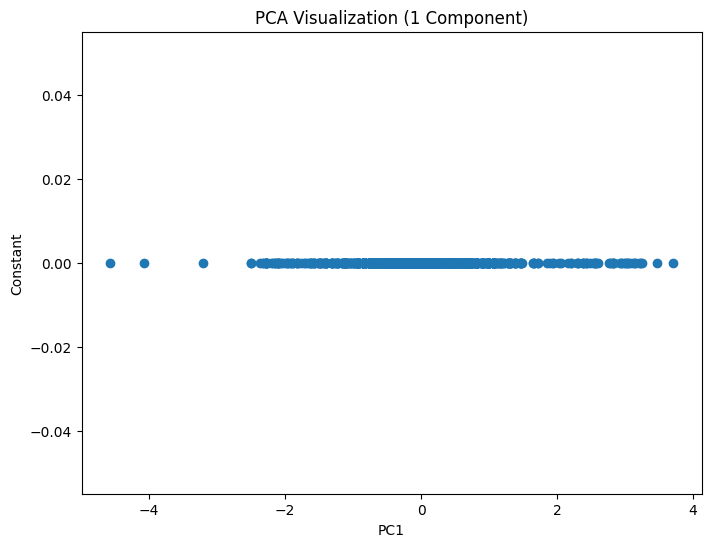

In [6]:
# Step 2: Filter data (example: TMAX)
df = df[df['element'] == 'TMAX']

# Step 3: Remove missing values
df = df.dropna(subset=['value'])

# Step 4: Select feature
X = df[['value']]

# Step 5: Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 6: Apply PCA (reduce to 1 component)
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_scaled)

# Step 7: Plot PCA
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], [0]*len(X_pca)) # Plotting against a constant for 1D data
plt.title("PCA Visualization (1 Component)")
plt.xlabel("PC1")
plt.ylabel("Constant") # Since we only have 1 component, the y-axis would be constant

In [7]:
significant_features = [] # Initialize significant_features as an empty list
significant_features.append('value')

# Re-creating 'Class' column for demonstration purposes if it was dropped
# Assuming 'value' is the feature of interest for classification
# You might need to adjust this logic based on how 'Class' was originally defined
if 'Class' not in df.columns:
    median_value = df['value'].median()
    df['Class'] = (df['value'] > median_value).astype(int)

df = df[significant_features + ['Class']]

inliers = df[df.Class==0]
ins = inliers.drop(['value'], axis=1)

outliers = df[df.Class==1]
outs = outliers.drop(['value'], axis=1)

ins.shape, outs.shape

((492, 1), (475, 1))

In [8]:
def normal_accuracy(values):

    tp=list(values).count(1)
    total=values.shape[0]
    accuracy=np.round(tp/total,4)

    return accuracy

def fraud_accuracy(values):

    tn=list(values).count(-1)
    total=values.shape[0]
    accuracy=np.round(tn/total,4)

    return accuracy

In [9]:
import numpy as np

state= 42

ISF = IsolationForest(random_state=state)
ISF.fit(ins)

normal_isf = ISF.predict(ins)
fraud_isf = ISF.predict(outs)

in_accuracy_isf=normal_accuracy(normal_isf)
out_accuracy_isf=fraud_accuracy(fraud_isf)
print("Accuracy in Detecting Normal Cases:", in_accuracy_isf)
print("Accuracy in Detecting Fraud Cases:", out_accuracy_isf)

Accuracy in Detecting Normal Cases: 0.0
Accuracy in Detecting Fraud Cases: 1.0
